In [1]:
import cira 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from os.path import exists

import yfinance as yf


SYMBOL = "AAPL" 
SYM_HIST_FILE = f'./{SYMBOL.replace("/", "_")}.csv'


In [2]:
from fredapi import Fred
fred_key = open("../FRED.key", "r").read()[:-1]

class FRED:
    def __init__(self, api_key:str):
        self.api_key = api_key
        self.client = Fred(api_key=self.api_key)
    
    def get(self, series_id:str, start:datetime, end:datetime) -> pd.DataFrame:
        return pd.DataFrame({series_id:self.client.get_series(series_id, start, end)})

fred = FRED(fred_key)

In [3]:
import yfinance as yf
from datetime import datetime

class YFinacne:
    def __init__(self) -> None:
        pass

    def get(self, ticker:str, start_date:datetime, end_date:datetime=datetime.now()):
        start_date = start_date.date().strftime("%Y-%m-%d")
        end_date = end_date.date().strftime("%Y-%m-%d")
        return yf.download(ticker, start=start_date, end=end_date, progress=False)

yf_client = YFinacne()

In [4]:
start_date = datetime(2016, 1, 1)
end_date = datetime.now()

<Axes: xlabel='Date'>

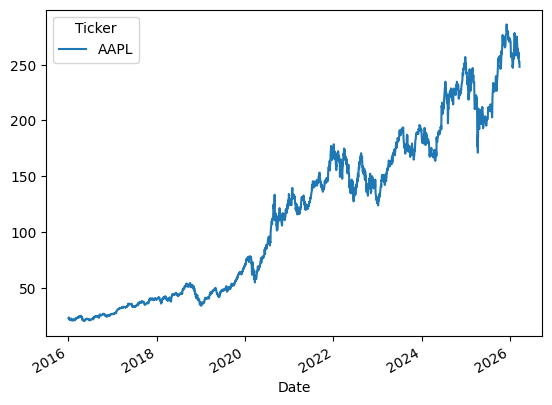

In [5]:
stock = yf_client.get(SYMBOL, start_date, end_date)
stock["Open"].plot()

<Axes: xlabel='Date'>

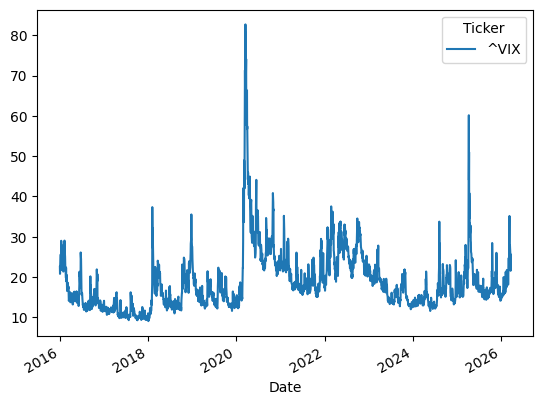

In [6]:
vix = yf_client.get("^VIX", start_date, end_date)
vix["Open"].plot()

<Axes: xlabel='Date'>

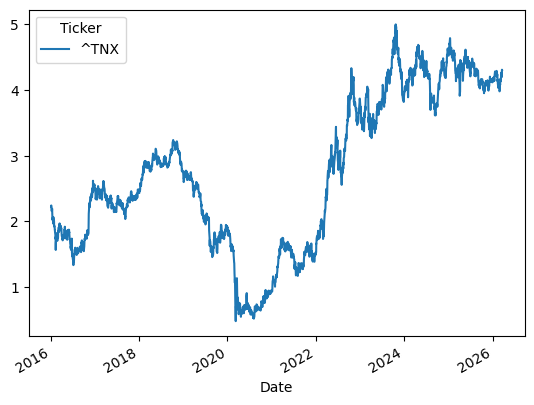

In [7]:
tnx = yf_client.get("^TNX", start_date, end_date)
tnx["Open"].plot()

<Axes: xlabel='Date'>

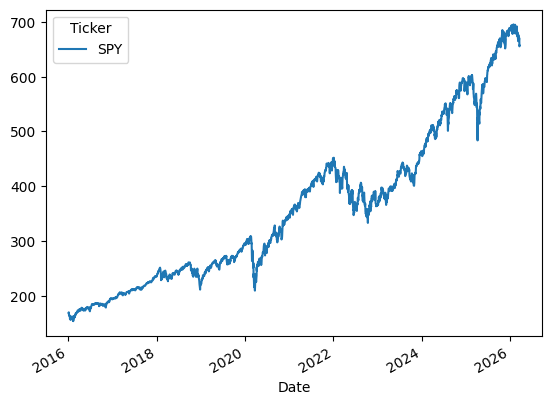

In [8]:
spy = yf_client.get("SPY", start_date, end_date)
spy["Open"].plot()

<Axes: xlabel='Date'>

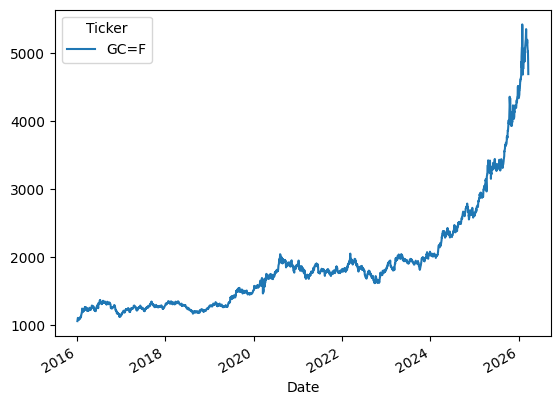

In [9]:
gold = yf_client.get("GC=F", start_date, end_date)
gold["Open"].plot()

<Axes: xlabel='Date'>

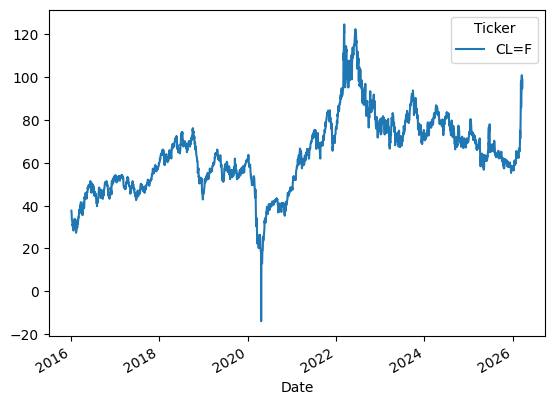

In [10]:
oil = yf_client.get("CL=F", start_date, end_date)
oil["Open"].plot()

<Axes: >

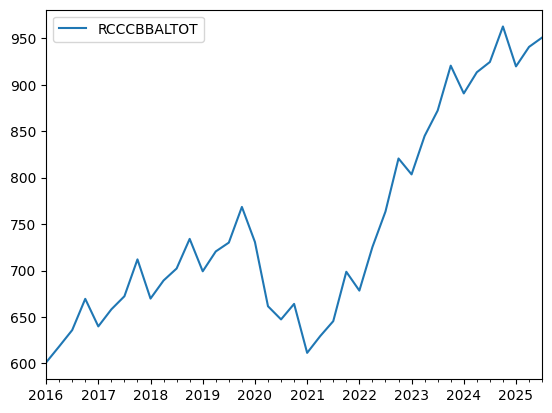

In [11]:
BANK_CREDIT = "RCCCBBALTOT" 
bank_credit = fred.get(BANK_CREDIT, start_date, end_date) 
bank_credit.plot()

<Axes: >

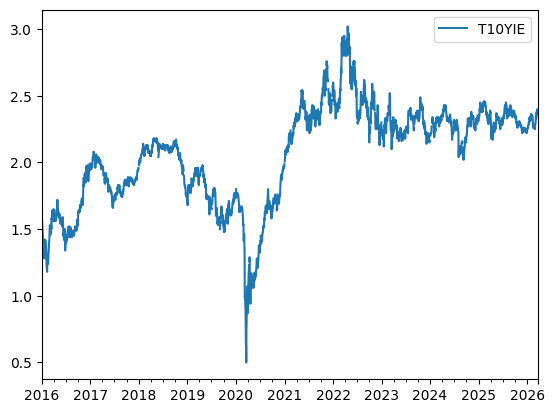

In [12]:
INFLATION = "T10YIE"
inflation = fred.get(INFLATION, start_date, end_date)
inflation.plot()

<Axes: >

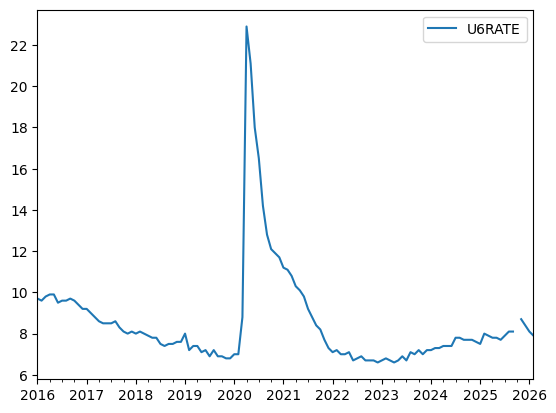

In [13]:
UNEMPLOYMENT = 'U6RATE'
unemployment = fred.get(UNEMPLOYMENT, start_date, end_date) 
unemployment.plot()

<Axes: >

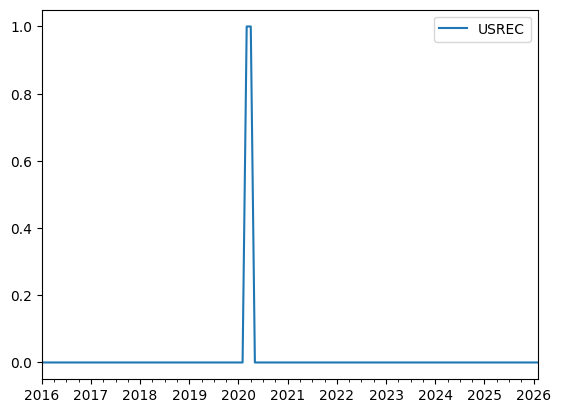

In [14]:
RECESSION = 'USREC'
recession = fred.get(RECESSION, start_date, end_date) 
recession.plot()

Ticker,AAPL,VIX,TNX,SPY,GOLD,OIL,RCCCBBALTOT,T10YIE,U6RATE
Date,,,,,,,,,
2026-03-16,252.110001,25.879999,4.236,666.559632,5001.600098,100.930000,NaN,2.36,NaN
2026-03-17,252.960007,24.559999,4.216,670.558691,5017.600098,94.410004,NaN,2.37,NaN
2026-03-18,252.630005,21.510000,4.197,666.539658,4949.600098,96.000000,NaN,2.40,NaN
2026-03-19,249.399994,25.600000,4.308,655.180681,4830.299805,99.129997,NaN,2.37,NaN
2026-03-20,247.979996,24.459999,4.304,656.510010,4686.899902,95.000000,NaN,2.38,NaN


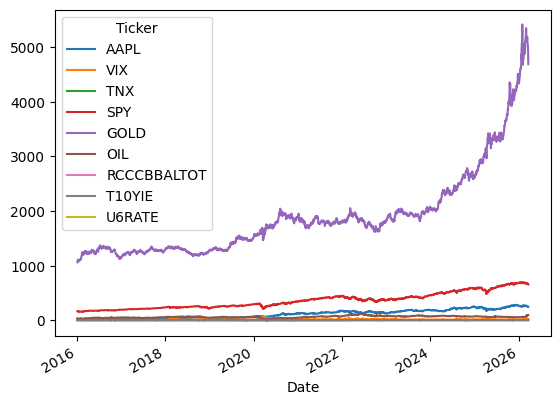

In [38]:
data = pd.DataFrame()
data = stock["Open"]
data_iters = zip(["VIX", "TNX", "SPY", "GOLD", "OIL", BANK_CREDIT, INFLATION, UNEMPLOYMENT], 
                 [vix, tnx, spy, gold, oil, bank_credit, inflation, unemployment])

for name, d in data_iters:
    if "Open" in d:
        data[name] = d["Open"]
    else: 
        data[name] = d
data.plot()
data.tail()

In [39]:
data.fillna(0.0, inplace=True)

Ticker,AAPL,VIX,TNX,SPY,GOLD,OIL,RCCCBBALTOT,T10YIE,U6RATE
Date,,,,,,,,,
2016-01-04,23.113739,22.480000,2.230,169.460171,1063.400024,37.599998,0.0,1.55,0.0
2016-01-05,23.821048,20.750000,2.243,170.229314,1075.599976,36.900002,0.0,1.56,0.0
2016-01-06,22.651959,21.670000,2.191,167.642941,1081.599976,36.180000,0.0,1.53,0.0
2016-01-07,22.228477,23.219999,2.163,165.098785,1091.599976,34.090000,0.0,1.50,0.0
2016-01-08,22.199191,22.959999,2.163,164.980428,1111.099976,33.299999,0.0,1.48,0.0
...,...,...,...,...,...,...,...,...,...
2026-03-16,252.110001,25.879999,4.236,666.559632,5001.600098,100.930000,0.0,2.36,0.0
2026-03-17,252.960007,24.559999,4.216,670.558691,5017.600098,94.410004,0.0,2.37,0.0
2026-03-18,252.630005,21.510000,4.197,666.539658,4949.600098,96.000000,0.0,2.40,0.0


In [41]:
split_prc = 0.9
train_data = data.iloc[:int(len(data)*split_prc)]
test_data =  data.iloc[int(len(data)*split_prc):]
print(len(data), len(train_data), len(test_data))
assert len(data) == len(train_data) + len(test_data)

2568 2311 257


In [47]:
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np

y = train_data["AAPL"]
X = train_data.drop(columns=["AAPL"])

In [50]:
model = make_pipeline(StandardScaler(), SVR(C=1.0, epsilon=0.2))
model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('svr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0


In [52]:
from sklearn.metrics import mean_squared_error, r2_score

y_test = test_data["AAPL"]
X_test = test_data.drop(columns=["AAPL"])

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSE: 9436.363064149655
R2: -10.108832343738987
